# EE446 - TinyML - Assignment 2

## Importing Libraries

In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from tensorflow.keras import datasets, layers,models
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Activation
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score
import c_writer
from os.path import join

## Reading Data

In [30]:
# Reading the data and adding column header (feature) names
data = pd.read_csv("Network_anomaly_data.txt",sep=",",names=["duration","protocoltype","service",
"flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised",
"rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate","rerrorrate","srvrerrorrate","samesrvrate",
"diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate",
"dsthostsamesrcportrate","dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate","dsthostrerrorrate",
"dsthostsrvrerrorrate","attack", "lastflag"])

In [31]:
data # printing the dataframe

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


## Question 1: Data Preprocessing

##### (a) Drop the 'land', 'urgent', 'numfailedlogins', 'numoutboundcmds' columns from the dataframe "data".

In [32]:
data.drop(columns=['land', 'urgent', 'numfailedlogins', 'numoutboundcmds'], inplace=True)

##### (b) Change any label that is not named normal to attack in the {'attack'} column of the dataframe data.

In [33]:
data['attack'] = data['attack'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

In [34]:
data #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,19
3,0,tcp,http,SF,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,attack,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,attack,20


##### (c) Use LabelEncoder() function from the sklearn.preprocessing library to convert non-numerical attributes in the {'protocoltype', 'service', 'flag', 'attack'} columns of the dataframe data to numerical values.

In [35]:
le = LabelEncoder()
for col in ['protocoltype', 'service', 'flag', 'attack']:
    data[col] = le.fit_transform(data[col])

In [36]:
pd.DataFrame(data) #<--------- Print your modified dataframe "data"

,duration,protocoltype,service,flag,srcbytes,dstbytes,wrongfragment,hot,loggedin,numcompromised,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,1,49,5,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,0,20
125969,8,2,49,9,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,1,21
125970,0,1,54,9,2231,384,0,0,1,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,1,18
125971,0,1,30,5,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,20


## Feature Scaling and Train/Test Split

In [37]:
# All the features apart from Attack are what we are going to use to predict the attack status of the data
# attack = 1 (normal/not an attack) and attack = 0 (attack)
X = data.drop(['attack'],axis=1).to_numpy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_normalized = scaler.fit_transform(X)

Y = data['attack'].to_numpy()
# Splitting X and y testing and training data
# we are taking 20% of the data for testing and 80% of the data for training
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size = 0.20)
# reshaping y test and train array
y_train = y_train.reshape(len(y_train),1)
y_test = y_test.reshape(len(y_test),1)

## Question 2: Dimensionality Reduction for Visualization

##### (a) Use TSNE from the sklearn.manifold library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

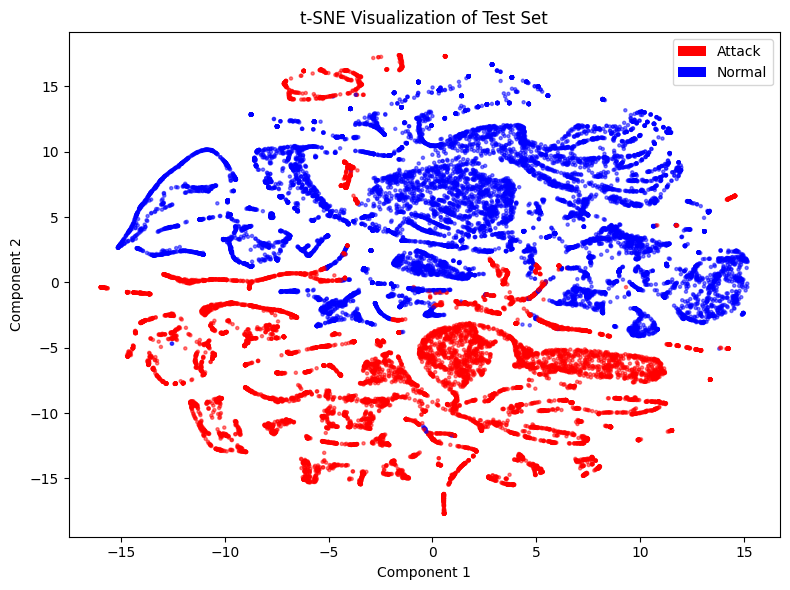

In [38]:
from sklearn.manifold import TSNE
from matplotlib.patches import Patch
tsne = TSNE(n_components=2, random_state=42, max_iter=300, perplexity=30)
X_tsne = tsne.fit_transform(X_test)

colors = ['red' if label == 0 else 'blue' for label in y_test.flatten()]
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.5, s=5)
legend_elements = [Patch(facecolor='red', label='Attack'), Patch(facecolor='blue', label='Normal')]
plt.legend(handles=legend_elements)
plt.title('t-SNE Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()

##### (b) Use PCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

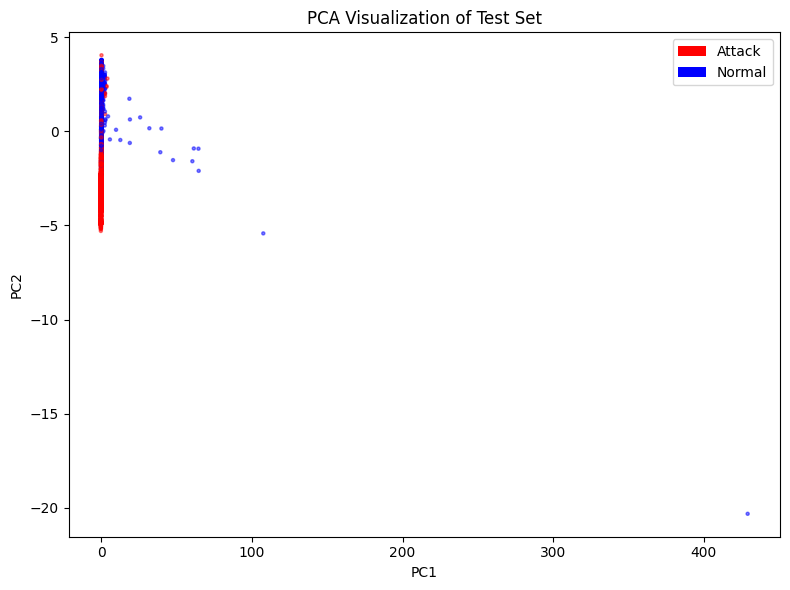

In [39]:
from sklearn.decomposition import PCA
from matplotlib.patches import Patch
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

colors = ['red' if label == 0 else 'blue' for label in y_test.flatten()]
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=5)
legend_elements = [Patch(facecolor='red', label='Attack'), Patch(facecolor='blue', label='Normal')]
plt.legend(handles=legend_elements)
plt.title('PCA Visualization of Test Set')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

##### (c) Use KernelPCA from the sklearn.decomposition library to visualize the data in the test set (X_test) in 2D. Use radial basis function (rbf) as the kernel. In your figure, use color "red" to mark {attack} data points and color "blue" to mark {normal} data points.

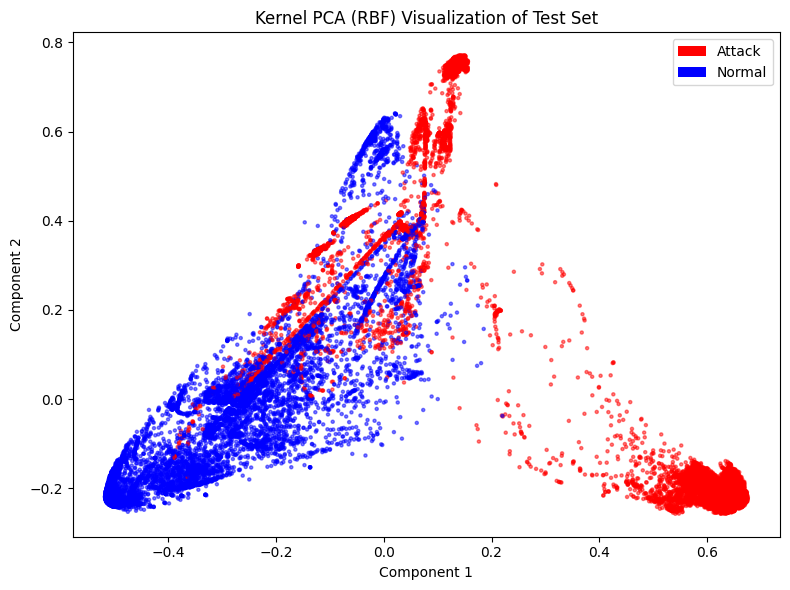

In [40]:
from sklearn.decomposition import KernelPCA
from matplotlib.patches import Patch
kpca = KernelPCA(n_components=2, kernel='rbf', random_state=42)
X_kpca = kpca.fit_transform(X_test)

colors = ['red' if label == 0 else 'blue' for label in y_test.flatten()]
plt.figure(figsize=(8, 6))
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=colors, alpha=0.5, s=5)
legend_elements = [Patch(facecolor='red', label='Attack'), Patch(facecolor='blue', label='Normal')]
plt.legend(handles=legend_elements)
plt.title('Kernel PCA (RBF) Visualization of Test Set')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.tight_layout()
plt.show()

## Question 3: Implementing a DNN on the dataset

##### (a) Implement a deep neural network (DNN) on the Network Anomaly Dataset. Ensure to include two neurons and softmax activation in the output layer of your DNN.

In [41]:
# Define the DNN model
input_dim = X_train.shape[1]

base_model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(2, activation='softmax')
])

##### (b) Compile and train your DNN model on the training set (X_train). Denote the trained model as base_model.

In [42]:
base_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history = base_model.fit(X_train, y_train,
                         epochs=10,
                         batch_size=256,
                         validation_split=0.1,
                         verbose=1)

Epoch 1/10
355/355 [==============================] - 0s 469us/step - loss: 0.0680 - accuracy: 0.9767 - val_loss: 0.0171 - val_accuracy: 0.9943
Epoch 2/10
355/355 [==============================] - 0s 371us/step - loss: 0.0123 - accuracy: 0.9958 - val_loss: 0.0093 - val_accuracy: 0.9959
Epoch 3/10
355/355 [==============================] - 0s 367us/step - loss: 0.0084 - accuracy: 0.9970 - val_loss: 0.0084 - val_accuracy: 0.9970
Epoch 4/10
355/355 [==============================] - 0s 368us/step - loss: 0.0070 - accuracy: 0.9974 - val_loss: 0.0070 - val_accuracy: 0.9969
Epoch 5/10
355/355 [==============================] - 0s 366us/step - loss: 0.0062 - accuracy: 0.9978 - val_loss: 0.0065 - val_accuracy: 0.9974
Epoch 6/10
355/355 [==============================] - 0s 369us/step - loss: 0.0051 - accuracy: 0.9982 - val_loss: 0.0058 - val_accuracy: 0.9976
Epoch 7/10
355/355 [==============================] - 0s 363us/step - loss: 0.0043 - accuracy: 0.9984 - val_loss: 0.0064 - val_accuracy:

##### (c) Evaluate the base_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

788/788 [==============================] - 0s 175us/step
Classification Report (base_model):
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11843
      Normal       1.00      1.00      1.00     13352

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



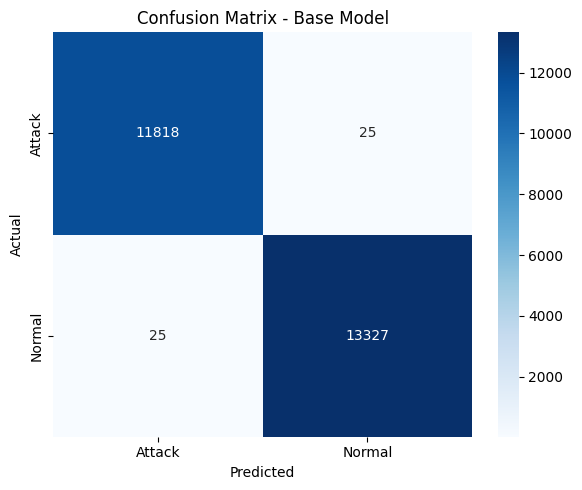

In [43]:
y_pred_probs = base_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print('Classification Report (base_model):')
print(classification_report(y_test, y_pred, target_names=['Attack', 'Normal']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix - Base Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [44]:
# Save the original Keras model to HDF5 file
base_model.save('original_model.h5')

## Question 4: Implementing Quantized Model

##### (a) Implement Dynamic Range Quantization on the base_model. Designate the resulting quantized ML model as tflite_quant_model.

In [57]:
# Load the trained model
base_model = tf.keras.models.load_model('original_model.h5')

def representative_data_gen():
    for sample in X_train[:100]:
        yield [sample.reshape(1, -1).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32
tflite_quant_model = converter.convert()

INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppbjw3xqy/assets


INFO:tensorflow:Assets written to: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppbjw3xqy/assets
2026-06-12 02:50:55.421839: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-12 02:50:55.421855: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-12 02:50:55.421981: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppbjw3xqy
2026-06-12 02:50:55.422412: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-12 02:50:55.422415: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/2y/vkd4h1tj22j6xmw68ffqhg1c0000gn/T/tmppbjw3xqy
2026-06-12 02:50:55.423722: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-12 02:50:55.439086: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

In [58]:
import os

# Save the quantized model
with open('quantized_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

# Get the file sizes
original_model_size = os.path.getsize('original_model.h5')
quantized_model_size = os.path.getsize('quantized_model.tflite')

# Print the model sizes
print(f"Original model size: {original_model_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_model_size / 1024:.2f} KB")

Original model size: 100.01 KB
Quantized model size: 8.66 KB


##### (b) Evaluate the tflite_quant_model on the test set (X_test) using classification_report and confusion_matrix from the sklearn.metrics library. Report these numbers in your .pdf writeup file using screenshots.

Classification Report (tflite_quant_model):
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11843
      Normal       1.00      1.00      1.00     13352

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



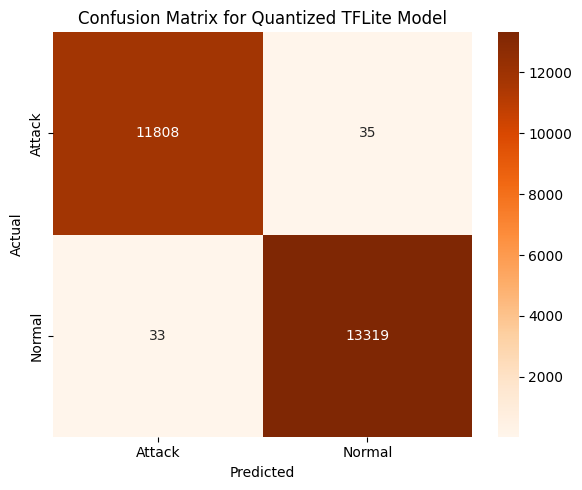

In [59]:
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_quant = []
for sample in X_test:
    input_data = np.array([sample], dtype=np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    y_pred_quant.append(np.argmax(output))

y_pred_quant = np.array(y_pred_quant)

print('Classification Report (tflite_quant_model):')
print(classification_report(y_test, y_pred_quant, target_names=['Attack', 'Normal']))

cm_quant = confusion_matrix(y_test, y_pred_quant)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_quant, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
plt.title('Confusion Matrix for Quantized TFLite Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Converting tflite_model to C and create the header file

In [60]:
# c_writer is a py file in the same folder and has been imported at the beginning of the notebook
# Reference : https://github.com/ShawnHymel/tinyml-example-anomaly-detection/blob/master/utils/c_writer.py
# We use #04x to pad the output to 2 digits with a 0x prefix
hex_array = [format(val, '#04x') for val in tflite_quant_model]
# Calling function to convert an array into a C string (requires Numpy)
# create_array(np_array, var_type, var_name, line_limit=80, indent=4)
c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', "network_model")
# Calling Function to create a header file with given C code as a string
header_str = c_writer.create_header(c_model, "network_model")

In [61]:
#Writing to the header file
with open('network_model.h', 'w') as file:
    file.write(header_str)

## Generating Samples for Inference on Arduino

In [62]:
# Converting a sample piece of the X test and y test data to C (for the purpose of ino code (arduino) to load and test
# the sample and compare

Xtest = X_test[0:5,:]
print(c_writer.create_array(Xtest,"float","X_test"))

const unsigned int X_test_dim1 = 5;
const unsigned int X_test_dim2 = 38;

const float X_test[5][38] = {
    -0.11024922321249885, -0.12470615670462065, -0.44208308523109213, 
    0.7511112872365361, -0.0077259564426604465, 0.002359683692860249, 
    -0.08948642202040107, -0.09507567152556495, 1.2356940323701657, 
    -0.011663642603760032, -0.036651869142258646, -0.024436507262009306, 
    -0.01238515036740332, -0.02618002418454278, -0.018609896340735923, 
    -0.04122119759327531, -0.0028174939213690777, -0.0975309439715147, 
    -0.6995794866568942, -0.25797130922872896, -0.6372092679572258, 
    -0.6319290328885425, -0.37436223991967527, -0.37443160310530493, 
    0.7712831058493207, -0.349683030873482, 0.47214949562686775, 
    -1.473189231082057, 1.2587542737799418, 1.0664013456654926, 
    -0.43907816809041417, -0.38310818187794965, 0.155090881452997, 
    -0.6395319051152512, -0.6248707997445304, -0.38763462350750655, 
    -0.3763870260680415, 0.6528228780141483, -0.110249223212